# Directed

In [2]:
# load the model from the file "sbm3x3_pclam_roc_0.210_auc_0.860"
import torch
from torch_geometric.transforms import TwoHop
from torch_geometric import utils as upyg

import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

from datasets.import_dataset import import_dataset
from utils.plotting import *
from trainer_directed import Trainer
import optimization_utils_directed as ou
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)
cpu = torch.device("cpu")

%load_ext autoreload
%autoreload 2


Using device: cpu


In [4]:

model_names = ['bigclam']
ds_names = ['elliptic']
densifiable_ds = ['photo','reddit']
num_reps = 1


config_triplets = [
    # ['feat_opt', 'n_iter', 2200],
    ['clamiter_init', 'dim_feat', 64],
    ['feat_opt', 'lr', 0.000005]
    ]

for model_name in model_names:    
    for ds_name in ds_names:
        #todo: make a data collection scheme
        
        ''' ds_to_use chooses whether to use the original dataset or the densified one. The trainer ds is the one that is used by the trainer that modifies it.'''
    
        ds = import_dataset(ds_name, to_undirected=False, remove_self_loops=False)
        ds_to_use = ds
        
        if ds_name in densifiable_ds:
            fat_ds = TwoHop()(ds)
            fat_ds.edge_attr = torch.ones(fat_ds.edge_index.shape[1]).bool()
            ds_to_use = fat_ds
    

        losseses = []
        acc_testses = []
        acc_valses = []
        try:
            for i in range(num_reps):
                trainer_anomaly = Trainer(
                    model_name=model_name,
                    device=device,
                    dataset=ds_to_use,
                    attr_opt=True,
                    task='anomaly_unsupervised',
                    metric='auc',
                    use_global_config_base=True,  
                    config_triplets_to_change=config_triplets          
                )
                
                losses, acc_test, acc_val = trainer_anomaly.train(
                    init_type='small_gaus',
                    init_feats=True,
                    acc_every=20,
                    plot_every=100,
                    verbose=False,
                    verbose_in_funcs=False,
                    normalize_degree=True
                )
                losseses.append(losses)
                acc_testses.append(acc_test)
                acc_valses.append(acc_val)
                

        except (Exception, KeyboardInterrupt) as e:
            raise e
        finally:
            if trainer_anomaly is not None:
                del trainer_anomaly
            del ds
            # del ds_to_use
            if ds_name in densifiable_ds:
                del fat_ds
            torch.cuda.empty_cache()

#todo: add timer to trainer!



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:315:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:155:::  



Using global config base





/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:339:::  

In function train. 
2026-03-30 21:21:53 starting optimization of bigclam on elliptic (DIRECTED) on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 24,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 5e-06,
        "n_iter": 2200,
        "early_stop": 0
    }
}


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_

UnboundLocalError: local variable 'acc_tracker' referenced before assignment



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



Using global config base





/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:339:::  

In function train. 
2026-04-19 00:20:21 starting optimization of bigclam on elliptic (DIRECTED) on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 64,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.0,
        "T": 1,
        "pow_in": 0.5,
        "pow_out": 0.5,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
     

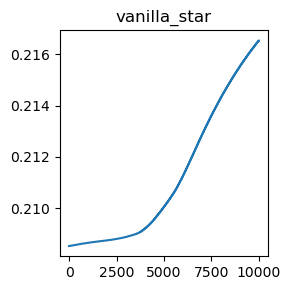

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.21652906171537373 
Best:
vanilla_star: 0.21652906171537373 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.21653006171537373




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 1057.5759029388428 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::

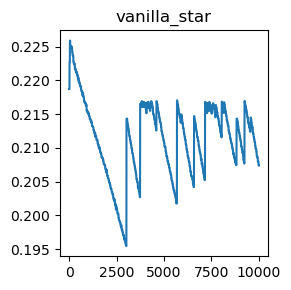

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.20738700659072812 
Best:
vanilla_star: 0.22590904569430037 at iteration 59


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.20738800659072812




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 1056.0346367359161 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  

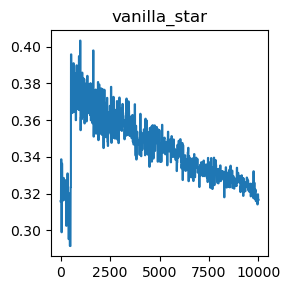

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.316561856206285 
Best:
vanilla_star: 0.40324533366658316 at iteration 999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.316562856206285




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 953.2629060745239 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  





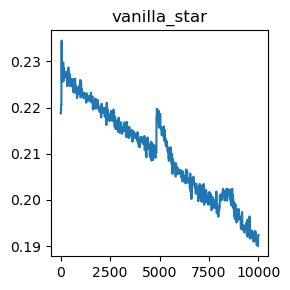

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.1924317119925113 
Best:
vanilla_star: 0.23447666672887973 at iteration 59


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.1924327119925113




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 955.9695479869843 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  




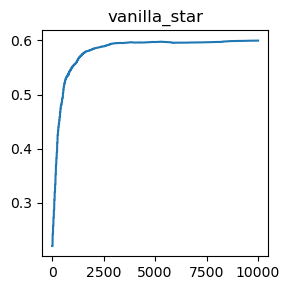

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.5997067357564604 
Best:
vanilla_star: 0.5997067357564604 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.5997077357564604




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 940.4696807861328 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



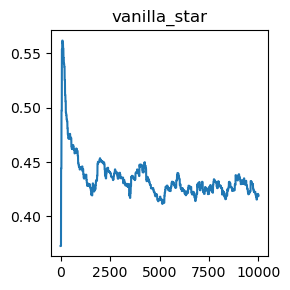

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.4191012168294575 
Best:
vanilla_star: 0.561871990813202 at iteration 99


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.4191022168294575




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 949.9750368595123 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



U

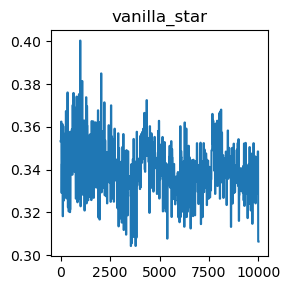

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.3062976447377622 
Best:
vanilla_star: 0.40030325790069915 at iteration 999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.3062986447377622




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 936.483433008194 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  




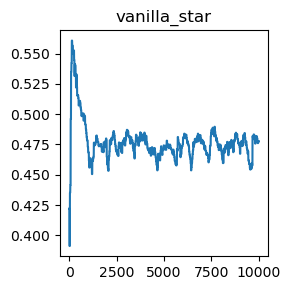

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.4776257709811195 
Best:
vanilla_star: 0.5606780482932638 at iteration 159


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.4776267709811195




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 932.2515473365784 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  




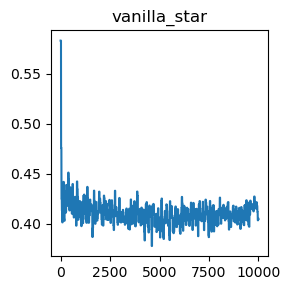

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.4050613466859961 
Best:
vanilla_star: 0.5832043791346981 at iteration 19


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.40506234668599606




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 951.9094359874725 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  




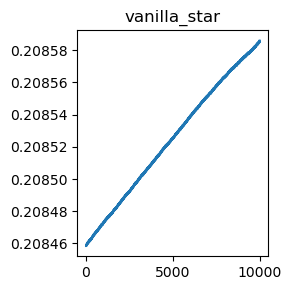

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.20858601899427978 
Best:
vanilla_star: 0.20858601899427978 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.20858701899427978




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 986.3960931301117 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157::: 

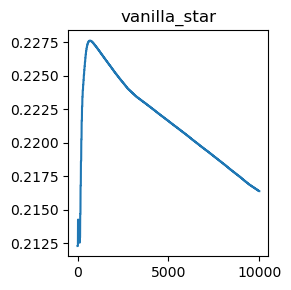

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.21638185423861564 
Best:
vanilla_star: 0.22761987520683438 at iteration 679


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.21638285423861564




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 953.4373180866241 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  

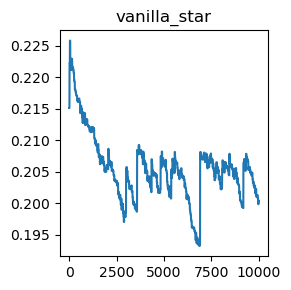

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.20037647280733864 
Best:
vanilla_star: 0.2258297843033992 at iteration 59


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.20037747280733864




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 957.4067151546478 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



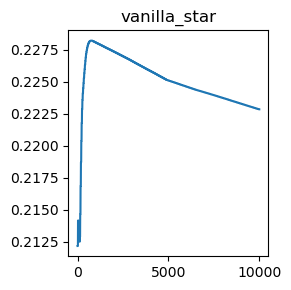

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.2228433334920008 
Best:
vanilla_star: 0.2282149384784996 at iteration 759


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.2228443334920008




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 942.013622045517 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  





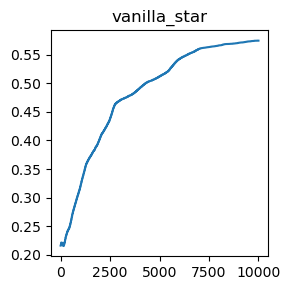

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.5743378519892993 
Best:
vanilla_star: 0.5744316177083498 at iteration 9979


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.5743388519892993




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 964.6325941085815 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



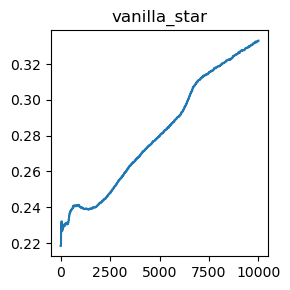

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.3331344436771498 
Best:
vanilla_star: 0.3331344436771498 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.33313544367714976




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 932.3738489151001 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  


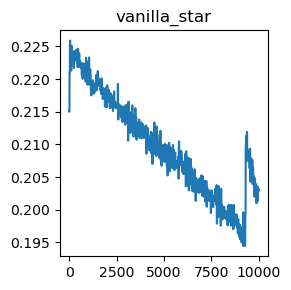

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.20295324567510595 
Best:
vanilla_star: 0.2258977364176552 at iteration 59


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.20295424567510595




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 960.415121793747 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  




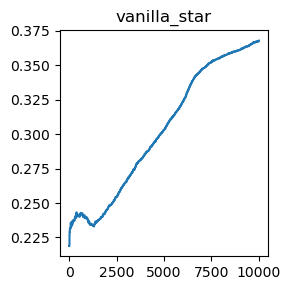

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.3679451748544383 
Best:
vanilla_star: 0.3679451748544383 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.36794617485443826




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 932.3425331115723 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  


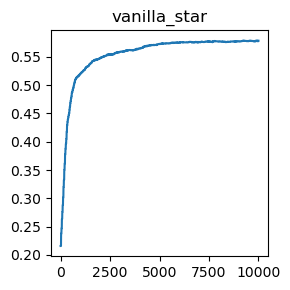

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.5786387650747352 
Best:
vanilla_star: 0.5788239092668069 at iteration 9259


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.5786397650747352




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 944.1174468994141 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



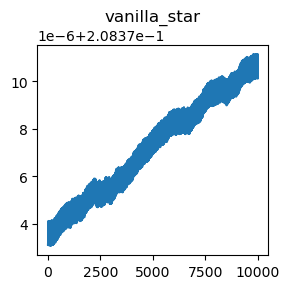

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.20838111371007453 
Best:
vanilla_star: 0.20838114385206988 at iteration 9899


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.20838211371007453




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 961.7840487957001 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157::: 

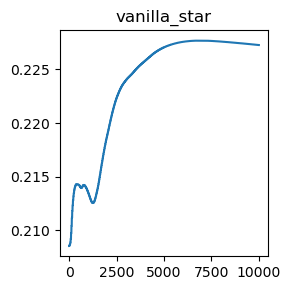

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.2272600882938618 
Best:
vanilla_star: 0.2276718761771655 at iteration 6899


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.2272610882938618




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 983.7799890041351 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



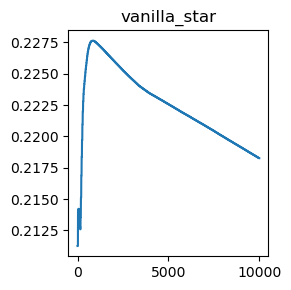

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.21826036969953014 
Best:
vanilla_star: 0.2276480760576585 at iteration 859


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.21826136969953014




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 935.5155141353607 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  


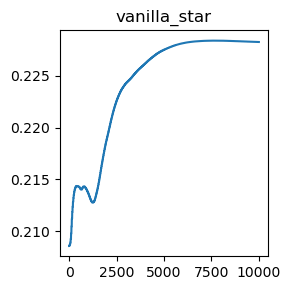

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.2282701103867387 
Best:
vanilla_star: 0.22840456177107615 at iteration 7779


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.2282711103867387




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 932.1261968612671 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  


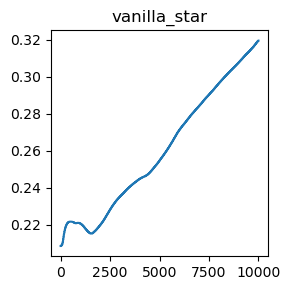

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.3194596955798331 
Best:
vanilla_star: 0.3194596955798331 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.3194606955798331




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 937.3029758930206 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



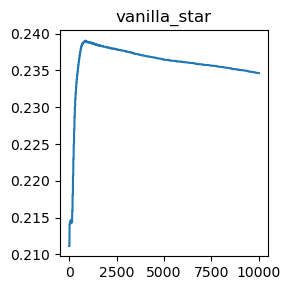

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.2346430806850576 
Best:
vanilla_star: 0.23906152946705578 at iteration 879


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.2346440806850576




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 941.1399869918823 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



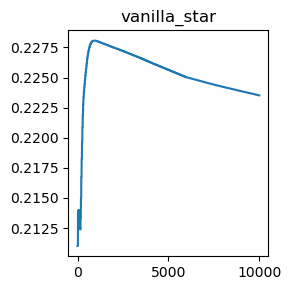

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.2235184599316428 
Best:
vanilla_star: 0.22806968420303841 at iteration 939


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.2235194599316428




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 931.9319632053375 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



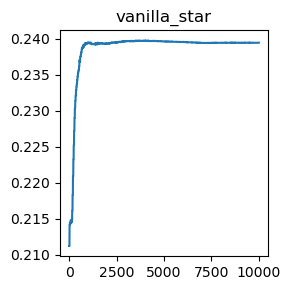

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.23943275225305388 
Best:
vanilla_star: 0.239716237719066 at iteration 3659


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.23943375225305388




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 923.538106918335 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



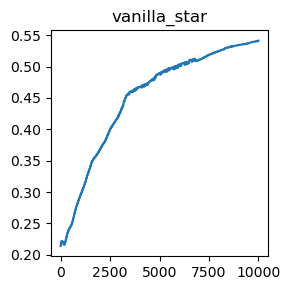

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.5414093618235474 
Best:
vanilla_star: 0.5414093618235474 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.5414103618235474




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 916.5073516368866 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



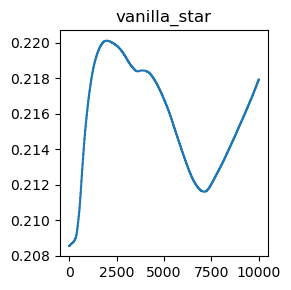

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.2179324006768204 
Best:
vanilla_star: 0.22012297018691412 at iteration 1999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.2179334006768204




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 805.7765688896179 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  


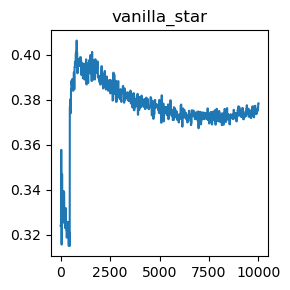

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.3784360963265829 
Best:
vanilla_star: 0.406323018269425 at iteration 819


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.3784370963265829




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 730.9540343284607 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  





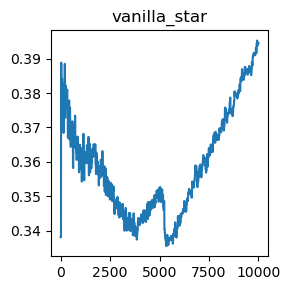

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.3945810653382004 
Best:
vanilla_star: 0.3952915784803515 at iteration 9939


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.3945820653382004




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 718.3630139827728 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



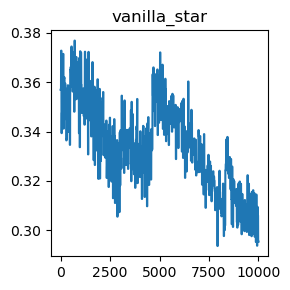

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.29540407443529576 
Best:
vanilla_star: 0.37684059008815446 at iteration 719


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.29540507443529573




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 714.9325261116028 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  

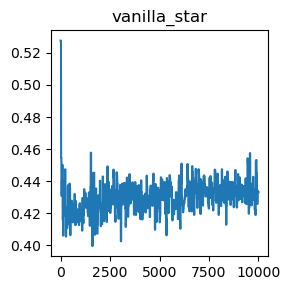

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.433009667873311 
Best:
vanilla_star: 0.5277025667568033 at iteration 19


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.433010667873311




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 725.0911538600922 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  



Us

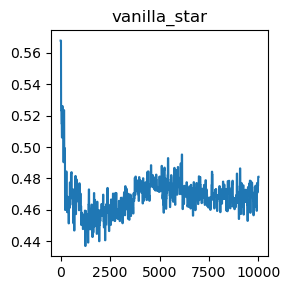

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.48108434792205906 
Best:
vanilla_star: 0.5677982687976334 at iteration 19


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.48108534792205904




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 4502.8162569999695 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  


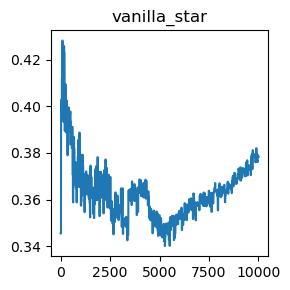

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.37830002330289714 
Best:
vanilla_star: 0.428118749343025 at iteration 99


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.3783010233028971




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 679.2905902862549 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  





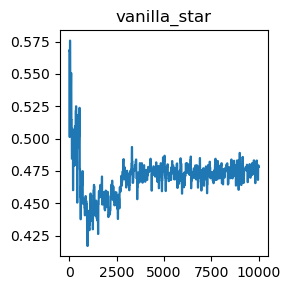

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.4781196475744857 
Best:
vanilla_star: 0.5758273729437734 at iteration 59


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.4781206475744857




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 752.6527092456818 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:839:::  
Repetition no. 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:316:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:157:::  





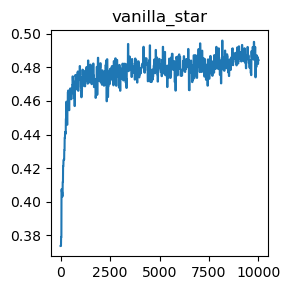

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.48438461307516345 
Best:
vanilla_star: 0.4959078858303203 at iteration 8179


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:454:::  



FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.4843856130751634




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer_directed.py:470:::  

train_model_on_params on bigclam elliptic 
took 769.1834790706635 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/optimization_utils_directed.py:898:::  


Finished CrossVal!




In [4]:
model_name = 'bigclam'
ds_names = ['elliptic']
densifiable_ds = ['photo', 'reddit']
n_reps = 1
use_global_config_base = True

#* perturb the global config
# deltas ={
# 'clamiter_init': {'s_reg': 0.001,
#                   'l1_reg': 0.001,
#                   'dim_feat': 2},
# 'feat_opt': {'n_iter': 50,
#             'lr': 0.0000001},
# 'prior_opt': {'n_iter': 50,
#               'lr': 0.0000001,
#               'noise_amp': 0.005},
# 'back_forth': {'scheduler_gamma' : 0.1}
# }

deltas = {}

range_triplets = ou.perturb_config('anomaly_unsupervised', 
                                   model_name, 
                                   deltas, 
                                   use_global_config=use_global_config_base)

range_triplets = [
    ['clamiter_init', 'dim_feat', [64]],
    ['clamiter_init', 'l1_reg', [0.0]],
    ['feat_opt', 'lr', [0.00001, 0.000001, 0.0000001, 0.0001]],
    ['clamiter_init', 'pow_in', [0.5, 0.1, 0]],
    ['clamiter_init', 'pow_out', [0.5, 0.1, 0]],
    ['feat_opt', 'n_iter', [10000]],
]

ou.multi_ds_anomaly(
    model_name,
    range_triplets,
    n_reps,
    metric='auc',
    use_global_config_base=use_global_config_base,
    device=device,
    ds_names=ds_names,
    densifiable_ds=densifiable_ds,
    acc_every=20,
    to_undirected=False,
    remove_self_loops=False,
    attr_opt=True,
    init_type='from_attr',
    name='softplus',
    plot_every=-1,    
)
#! for elliptic remember (from pieclam) that tuning down the lr could lead to convergence. the graph is very sparse.


## Tests

In [ ]:
elliptic_directed = import_dataset('elliptic', to_undirected=False, remove_self_loops=False)

elliptic_undirected = import_dataset('elliptic', to_undirected=True, remove_self_loops=False)

# elliptic_undirected = import_dataset('elliptic', to_undirected=True, remove_self_loops=True)



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:313:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


In [77]:
elliptic_undirected = import_dataset('elliptic', to_undirected=False, remove_self_loops=False)




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../datasets/import_dataset.py:315:::  
end of import_dataset
elliptic 
has 35874 nodes 
and 36624 edges. 
Graph is directed
Graph has NO self loops


In [79]:
elliptic_undirected.raw_attr

tensor([[ 0.1631,  1.9638, -0.6464,  ...,  0.6778, -0.1206, -0.1198],
        [-0.0050,  0.5789, -0.0914,  ...,  0.3332, -0.1206, -0.1198],
        [-0.1479, -0.1847, -1.2014,  ..., -0.0975, -0.1206, -0.1198],
        ...,
        [-0.1704, -0.0782,  1.0186,  ..., -0.0975, -0.1206, -0.1198],
        [-0.0937, -0.1162,  1.0186,  ..., -0.0975, -0.1206, -0.1198],
        [-0.1720, -0.0782,  1.0186,  ..., -0.0975, -0.1206, -0.1198]])

In [66]:
(upyg.to_undirected(elliptic_directed.edge_index) - elliptic_undirected.edge_index).sum()

#maybe the classification is the same? no i need something different for the  

tensor(0)

In [72]:
elliptic_undirected.raw_attr.shape

(35874, 93)

In [69]:
elliptic_directed.x.shape

torch.Size([35874, 165])

# Undirected

In [1]:
# load the model from the file "sbm3x3_pclam_roc_0.210_auc_0.860"
import torch
from torch_geometric.transforms import TwoHop

import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

from datasets.import_dataset import import_dataset
from utils.plotting import *
from trainer import Trainer
import optimization_utils as ou
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)
cpu = torch.device("cpu")

%load_ext autoreload
%autoreload 2


/Users/danielzilberg/anaconda3/envs/pyg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [ ]:
%who

# Reproduce Anomaly Detection experiment
use best global params from hypers/hypers_link_prediction.yaml. 

IeClam



/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:157:::  


Using global config base





/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:335:::  
 2025-05-17 22:11:48 starting optimization of ieclam on photo on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 2000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/ICML_pieclam/experiments/../clamiter.py:364:::  staring fit_feats for 2000 iterations


/home/user/Documents/danny/ICML_pieclam/experiments/../clamiter.py:392:::  
fit wrapper fit_feats, plotting state at iter 1999


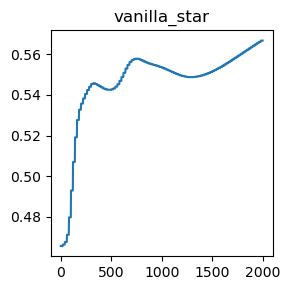

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.566792891247397 
Best:
vanilla_star: 0.566792891247397 at iteration 1999


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:436:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.566793891247397




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:452:::  
train_model_on_params on ieclam photo 
took 79.6026918888092 seconds


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:157:::  


Using global config base





/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:335:::  
 2025-05-17 22:13:09 starting optimization of ieclam on reddit on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter":

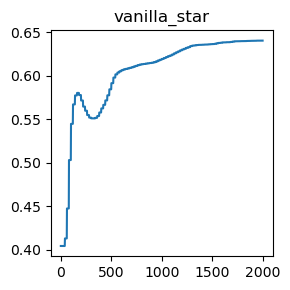

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.6405192919611712 
Best:
vanilla_star: 0.640547340012372 at iteration 1979


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:436:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.6405202919611712




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:452:::  
train_model_on_params on ieclam reddit 
took 255.5393829345703 seconds


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:157:::  


Using global config base





/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:335:::  
 2025-05-17 22:17:25 starting optimization of ieclam on elliptic on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_

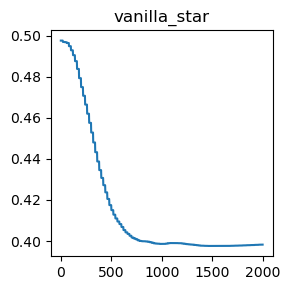

ANOMALY_UNSUPERVISED TEST accuracy.
Latest:
vanilla_star: 0.39825914834587967 
Best:
vanilla_star: 0.49755998065076806 at iteration 19


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:436:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.39826014834587964




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:452:::  
train_model_on_params on ieclam elliptic 
took 6.109010934829712 seconds


In [ ]:

model_names = ['ieclam']
ds_names = ['photo', 'reddit', 'elliptic']
densifiable_ds = ['photo','reddit']
num_reps = 1


config_triplets = [
    # ['feat_opt', 'n_iter', 2200]
    ]

for model_name in model_names:    
    for ds_name in ds_names:
        #todo: make a data collection scheme
        
        ''' ds_to_use chooses whether to use the original dataset or the densified one. The trainer ds is the one that is used by the trainer that modifies it.'''
        ds = import_dataset(ds_name)
        ds_to_use = ds
        
        if ds_name in densifiable_ds:
            '''densification is pretty straightforward in both anomaly detection and link prediction'''
            fat_ds = TwoHop()(ds)
            fat_ds.edge_attr = torch.ones(fat_ds.edge_index.shape[1]).bool()
            ds_to_use = fat_ds
    

        losseses = []
        acc_testses = []
        acc_valses = []
        try:
            for i in range(num_reps):
                trainer_anomaly = Trainer(
                    model_name=model_name,
                    device=device,
                    dataset=ds_to_use,
                    attr_opt=True,
                    task='anomaly_unsupervised',
                    metric='auc',
                    use_global_config_base=True,  
                    config_triplets_to_change=config_triplets          
                )
                
                losses, acc_test, acc_val = trainer_anomaly.train(
                    init_type='small_gaus',
                    init_feats=True,
                    acc_every=20,
                    plot_every=-1,
                    verbose=False,
                    verbose_in_funcs=False
                )
                losseses.append(losses)
                acc_testses.append(acc_test)
                acc_valses.append(acc_val)
                

        except (Exception, KeyboardInterrupt) as e:
            raise e
        finally:
            if trainer_anomaly is not None:
                del trainer_anomaly
            del ds
            # del ds_to_use
            if ds_name in densifiable_ds:
                del fat_ds
            torch.cuda.empty_cache()

#todo: add timer to trainer!

PieClam

/home/user/anaconda3/envs/piegam/lib/python3.11/site-packages/torch_geometric/edge_index.py:784: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1711403378171/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_csr_tensor(




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:157:::  


Using global config base





/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:335:::  
 2025-05-17 21:55:26 starting optimization of pieclam on photo on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 3e-06,
        "n_iter": 500,
        "early_stop": 0
    },
    "prior_opt": {
        "n_iter": 1300,
        "lr": 2e-06,
        "noise_amp": 0.05,
        "weight_decay": 0.1,
        "early_stop": 0
    },
    "back_forth": {
        "n_back_forth": 3,
        "scheduler_step_size": 1,
        "scheduler_gamma": 0.5,
        "early_stop_fit": 0,
        "first_func_in_fit": "fit_feats"
    }
}


/home/user/Documents/danny/ICML_pieclam/experiments/../

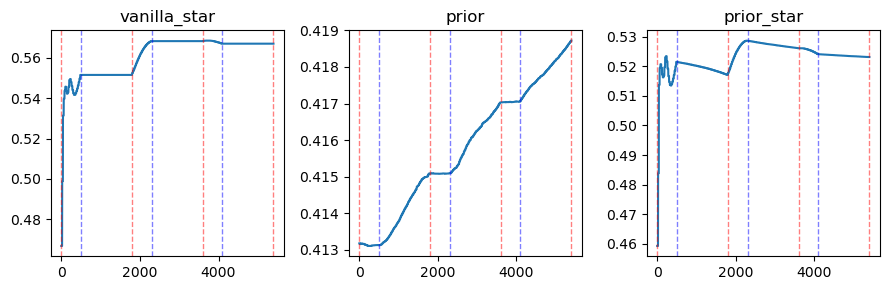



/home/user/Documents/danny/ICML_pieclam/experiments/../clamiter.py:704:::  
fit end, no early stopping


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:436:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.5669575465311157
test
key='prior': 0.41872169181677477
test
key='prior_star': 0.5231304100962528




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:452:::  
train_model_on_params on pieclam photo 
took 202.2672290802002 seconds


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:157:::  


Using global config base





/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:335:::  
 2025-05-17 21:58:49 starting optimization of pieclam on reddit on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },


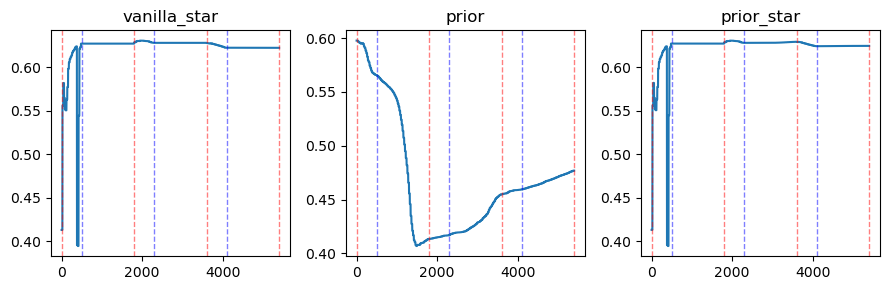



/home/user/Documents/danny/ICML_pieclam/experiments/../clamiter.py:704:::  
fit end, no early stopping


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:436:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.6221672169169377
test
key='prior': 0.4769030145674887
test
key='prior_star': 0.6243265308770445




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:452:::  
train_model_on_params on pieclam reddit 
took 374.08334469795227 seconds


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:157:::  


Using global config base





/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:335:::  
 2025-05-17 22:05:04 starting optimization of pieclam on elliptic on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 93,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    

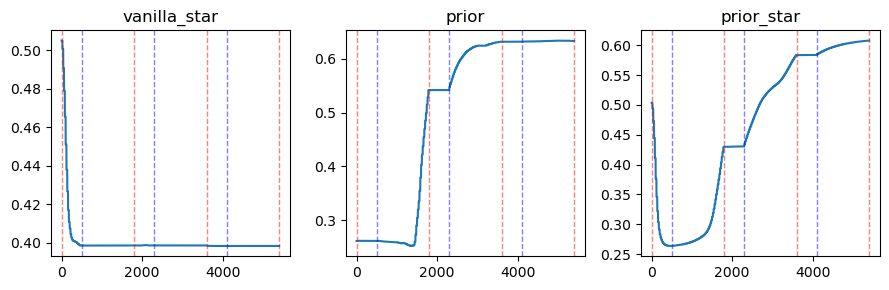



/home/user/Documents/danny/ICML_pieclam/experiments/../clamiter.py:704:::  
fit end, no early stopping


/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:436:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.39835133391013056
test
key='prior': 0.6330024571937851
test
key='prior_star': 0.607950184945496




/home/user/Documents/danny/ICML_pieclam/experiments/../trainer.py:452:::  
train_model_on_params on pieclam elliptic 
took 402.9796152114868 seconds


In [ ]:

model_names = ['pieclam']
ds_names = ['photo', 'reddit', 'elliptic']
densifiable_ds = ['photo','reddit', 'elliptic']
num_reps = 1


config_triplets = [
    # ['feat_opt', 'n_iter', 2200]
    ]

for model_name in model_names:    
    for ds_name in ds_names:
        #todo: make a data collection scheme
        
        ''' ds_to_use chooses whether to use the original dataset or the densified one. The trainer ds is the one that is used by the trainer that modifies it.'''
        ds = import_dataset(ds_name)
        ds_to_use = ds
        
        if ds_name in densifiable_ds:
            fat_ds = TwoHop()(ds)
            fat_ds.edge_attr = torch.ones(fat_ds.edge_index.shape[1]).bool()
            ds_to_use = fat_ds
    

        losseses = []
        acc_testses = []
        acc_valses = []
        try:
            for i in range(num_reps):
                trainer_anomaly = Trainer(
                    model_name=model_name,
                    device=device,
                    dataset=ds_to_use,
                    attr_opt=True,
                    task='anomaly_unsupervised',
                    metric='auc',
                    use_global_config_base=True,  
                    config_triplets_to_change=config_triplets          
                )
                
                losses, acc_test, acc_val = trainer_anomaly.train(
                    init_type='small_gaus',
                    init_feats=True,
                    acc_every=20,
                    plot_every=-1,
                    verbose=False,
                    verbose_in_funcs=False
                )
                losseses.append(losses)
                acc_testses.append(acc_test)
                acc_valses.append(acc_val)
                

        except (Exception, KeyboardInterrupt) as e:
            raise e
        finally:
            if trainer_anomaly is not None:
                del trainer_anomaly
            del ds
            # del ds_to_use
            if ds_name in densifiable_ds:
                del fat_ds
            torch.cuda.empty_cache()

#todo: add timer to trainer!



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:320:::  
 2025-03-29 17:53:04 starting optimization of pieclam on elliptic on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 93,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 3e-06,
        "n_iter": 500,
        "early_stop": 0
    },
    "prior_opt": {
        "n_iter": 1300,
        "lr": 2e-06,
        "noise_amp": 0.05,
        "weight_decay": 0.1,
        "early_stop": 0
    },
    "back_forth": {
        "n_back_forth": 3,
        "scheduler_step_size": 1,
        "scheduler_gamma": 0.5,
        "early_stop_fit": 0,
        "first_func_in_fit": "fit_feats"
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:557:::  
in fit,
first_func_in_fit='fit_feats'
second_function_name='fit_prior'


/home/user/

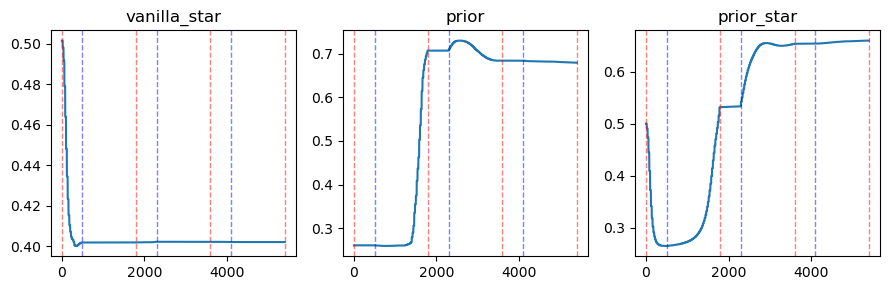



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:681:::  
fit end, no early stopping


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:422:::  


FINISHED train 
 last accuracies:
test
key='vanilla_star': 0.40208516152395996
test
key='prior': 0.6790048087516922
test
key='prior_star': 0.6596578676337185


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:436:::  





In [ ]:
#WORKING EXAMPLE DO NOT TOUCH
model_names = ['pieclam']
ds_names = ['elliptic']
densifiable_ds = ['photo','reddit']
num_reps = 1


config_triplets = [
    # ['feat_opt', 'n_iter', 2200]
    ]

for model_name in model_names:    
    for ds_name in ds_names:
        #todo: make a data collection scheme
        
        ''' ds_to_use chooses whether to use the original dataset or the densified one. The trainer ds is the one that is used by the trainer that modifies it.'''
        ds = import_dataset(ds_name)
        ds_to_use = ds
        
        if ds_name in densifiable_ds:
            fat_ds = TwoHop()(ds)
            fat_ds.edge_attr = torch.ones(fat_ds.edge_index.shape[1]).bool()
            ds_to_use = fat_ds
    

        losseses = []
        acc_testses = []
        acc_valses = []
        try:
            for i in range(num_reps):
                trainer_anomaly = Trainer(
                    model_name=model_name,
                    device=device,
                    dataset=ds_to_use,
                    attr_opt=True,
                    task='anomaly_unsupervised',
                    metric='auc',
                    use_global_config_base=True,  
                    config_triplets_to_change=config_triplets          
                )
                
                losses, acc_test, acc_val = trainer_anomaly.train(
                    init_type='small_gaus',
                    init_feats=True,
                    acc_every=20,
                    plot_every=-1,
                    verbose=False,
                    verbose_in_funcs=False
                )
                losseses.append(losses)
                acc_testses.append(acc_test)
                acc_valses.append(acc_val)
                

        except (Exception, KeyboardInterrupt) as e:
            raise e
        finally:
            if trainer_anomaly is not None:
                del trainer_anomaly
            del ds
            # del ds_to_use
            if ds_name in densifiable_ds:
                del fat_ds
            torch.cuda.empty_cache()

#todo: add timer to trainer!

# Hypers Search
Scan experiment for parameter ranges. One can give parameter ranges or deltas for the global configuration as shown below.

In [ ]:
model_name = 'pieclam'
ds_names = ['elliptic', 'photo', 'reddit']
densifiable_ds = ['photo', 'reddit']
n_reps = 1
use_global_config_base = True

#* perturb the global config
deltas ={
'clamiter_init': {'s_reg': 0.001,
                  'l1_reg': 0.001,
                  'dim_feat': 2},
'feat_opt': {'n_iter': 50,
            'lr': 0.0000001},
'prior_opt': {'n_iter': 50,
              'lr': 0.0000001,
              'noise_amp': 0.005},
'back_forth': {'scheduler_gamma' : 0.1}
}

range_triplets = ou.perturb_config('anomaly_unsupervised', 
                                   model_name, 
                                   deltas, 
                                   use_global_config=use_global_config_base)



ou.multi_ds_anomaly(
    model_name,
    range_triplets,
    n_reps,
    metric='auc',
    use_global_config_base=use_global_config_base,
    device=device,
    ds_names=ds_names,
    densifiable_ds=densifiable_ds,
    attr_opt=True,
    plot_every=-1
    
)



In [ ]:
#todo: show the ranges at the beginning of the optimization
#todo: make analysis file to gather results together

In [ ]:
#TODO: GIT SHIT

# Ablation Study: Densification

In [ ]:

# ABLATION STUDY WITHOUT DENSIFICATION

model_names = ['pieclam']
ds_names = ['photo', 'elliptic', 'reddit']


final_accs = {'photo': {'vanilla_star':[],'prior':[],'prior_star':[]}, 'elliptic': {'vanilla_star':[],'prior':[],'prior_star':[]}, 'reddit': {'vanilla_star':[],'prior':[],'prior_star':[]}}

for model_name in model_names:    
    for ds_name in ds_names:
        
        ds = import_dataset(ds_name)
        for _ in range(10):   
            #! NOTICE: no densification!
            ds_to_use = ds

            
 
            # config_triplets = [['feat_opt', 'n_iter', 20],
            #                 ['prior_opt', 'n_iter', 20],]
            config_triplets = []

            trainer_anomaly = Trainer(
                model_name=model_name,
                device=device,
                dataset=ds_to_use.clone(),
                attr_opt=True,
                task='anomaly_unsupervised',
                use_global_configs_base=True,
                config_triplets_to_change=config_triplets
            )

            losses, acc_test, acc_val = trainer_anomaly.train(
                init_type='small_gaus',
                init_feats=True,
                acc_every=20,
                plot_every=10000,
                verbose=False,
                verbose_in_funcs=False
            )

            final_accs[ds_name]['vanilla_star'].append(acc_test['vanilla_star'][-1])
            final_accs[ds_name]['prior'].append(acc_test['prior'][-1])
            final_accs[ds_name]['prior_star'].append(acc_test['prior_star'][-1])

        if trainer_anomaly.clamiter.prior is not None:
            del trainer_anomaly.clamiter.prior.model
        del trainer_anomaly.data
        torch.cuda.empty_cache()

        del ds
        del ds_to_use
       
        torch.cuda.empty_cache()



In [ ]:
# get mean and std for final accuracies.
for key in final_accs:
    print(key)
    for key2 in final_accs[key]:
        print(key2, np.mean(final_accs[key][key2]), np.std(final_accs[key][key2]))